In [1]:
# --- replication package paths (auto-inserted) ---
from pathlib import Path

# Resolve the package root whether run from notebooks/ or the root.
_here = Path.cwd()
ROOT = _here if (_here / "data").exists() else _here.parent

DATA    = ROOT / "data"
RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"
RESULTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

assert DATA.exists(), f"data folder not found: {DATA}"


[H2] 0 / 1183182 rows (0.00%) have no base_repository_url and are excluded from per-project aggregation.
Conflicting License (Category 3): n=10337, Gini=0.961, top 2.5% of projects account for 80% of conflicting license (category 3)
High Risk (Category 4): n=10337, Gini=0.992, top 0.6% of projects account for 80% of high risk (category 4)
Actionable Debt (Category 3+4, combined): n=10337, Gini=0.960, top 2.6% of projects account for 80% of actionable debt (category 3+4, combined)
LCD Density: n=8407, Gini=0.740, top 20.7% of projects account for 80% of lcd density


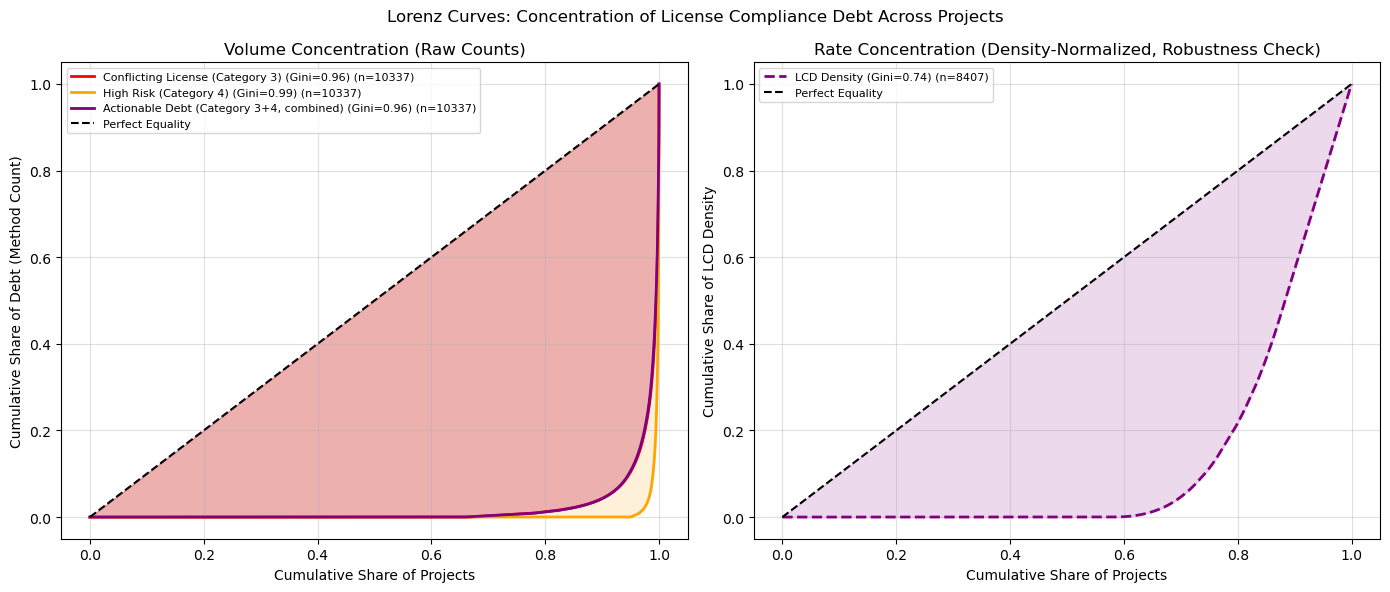

In [2]:
"""
H2 Analysis: Concentration of License Compliance Debt
------------------------------------------------------------------------
UPDATE: project identity resolution simplified using base_repository_url,
now confirmed to be the clean, canonical query-project root URL,
populated consistently across all categories including Category 0
(where sink_repository_url is null). This replaces the prior
is_cat0-based swap between source_repository_url/sink_repository_url
plus regex-based root extraction, which is no longer needed.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def process_repo_debt_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Processes the raw method-level DataFrame into project-level debt
    metrics, using base_repository_url directly as project identity.
    """
    df = df.copy()
    df["org"] = df["organization_name"].str.lower()

    unresolved_mask = df["base_repository_url"].isna()
    n_unresolved = unresolved_mask.sum()
    print(f"[H2] {n_unresolved} / {len(df)} rows ({n_unresolved/len(df):.2%}) have no "
          f"base_repository_url and are excluded from per-project aggregation.")
    if n_unresolved > 0:
        print(f"[H2] Unresolved rows by category:\n"
              f"{df.loc[unresolved_mask, 'violation_lcd_category'].value_counts().sort_index()}")

    df_resolved = df.dropna(subset=["base_repository_url"])

    category_counts = (
        pd.crosstab(
            index=[df_resolved["org"], df_resolved["base_repository_url"], df_resolved["project_type"]],
            columns=df_resolved["violation_lcd_category"],
        )
        .reindex(columns=[0, 1, 2, 3, 4, 5], fill_value=0)
        .reset_index()
        .rename(columns={
            0: "cat0_no_match", 1: "cat1_same_license", 2: "cat2_compatible",
            3: "cat3_conflicts", 4: "cat4_high_risk", 5: "cat5_undetermined",
        })
    )

    category_counts["total_methods"] = category_counts[
        ["cat0_no_match", "cat1_same_license", "cat2_compatible",
         "cat3_conflicts", "cat4_high_risk", "cat5_undetermined"]
    ].sum(axis=1)

    projects_df = category_counts[category_counts["total_methods"] > 0].copy()
    projects_df["actionable"] = projects_df["cat3_conflicts"] + projects_df["cat4_high_risk"]
    projects_df["density_denominator"] = projects_df["total_methods"] - projects_df["cat0_no_match"]
    projects_df["density"] = np.where(
        projects_df["density_denominator"] > 0,
        projects_df["actionable"] / projects_df["density_denominator"],
        np.nan,
    )

    return projects_df


def gini_coefficient(values):
    values = np.asarray(values, dtype=float)
    values = values[values >= 0]
    if len(values) == 0:
        return np.nan
    values = np.sort(values)
    n = len(values)
    total = values.sum()
    if total == 0:
        return np.nan
    cumvals = np.cumsum(values)
    return (n + 1 - 2 * np.sum(cumvals) / cumvals[-1]) / n


def lorenz_curve(values):
    values = np.asarray(values, dtype=float)
    values = np.sort(values[values >= 0])
    n = len(values)
    total = values.sum()
    cum_projects = np.insert(np.arange(1, n + 1) / n, 0, 0)
    cum_values = (
        np.insert(np.cumsum(values) / total, 0, 0) if total > 0 else np.zeros(n + 1)
    )
    gini = gini_coefficient(values)
    return cum_projects, cum_values, gini, n


def pareto_crossing(cum_projects, cum_values, target=0.80):
    reversed_projects = 1 - cum_projects
    reversed_values = 1 - cum_values
    idx = np.searchsorted(reversed_values[::-1], target)
    if idx >= len(reversed_values):
        return None
    return reversed_projects[::-1][idx]


def plot_lorenz(ax, cum_projects, cum_values, label, color, n, linestyle="-"):
    ax.plot(cum_projects, cum_values, label=f"{label} (n={n})", color=color, lw=2, linestyle=linestyle)
    ax.fill_between(cum_projects, cum_values, cum_projects, color=color, alpha=0.15)


def summarize(name, cum_projects, cum_values, gini, n):
    crossing = pareto_crossing(cum_projects, cum_values, target=0.80)
    if crossing is not None:
        print(f"{name}: n={n}, Gini={gini:.3f}, "
              f"top {crossing*100:.1f}% of projects account for 80% of {name.lower()}")
    else:
        print(f"{name}: n={n}, Gini={gini:.3f}, 80% threshold not reached")


if __name__ == "__main__":
    df = pd.read_csv(DATA / "license_analysis_results_processed.csv")

    projects_df = process_repo_debt_data(df)

    conflicts = projects_df["cat3_conflicts"].values
    highrisk = projects_df["cat4_high_risk"].values
    actionable = projects_df["actionable"].values
    densities = projects_df["density"].dropna().values

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    for values, label, color in [
        (conflicts, "Conflicting License (Category 3)", "red"),
        (highrisk, "High Risk (Category 4)", "orange"),
        (actionable, "Actionable Debt (Category 3+4, combined)", "purple"),
    ]:
        cp, cv, gini, n = lorenz_curve(values)
        plot_lorenz(ax, cp, cv, f"{label} (Gini={gini:.2f})", color, n)
        summarize(label, cp, cv, gini, n)

    ax.plot([0, 1], [0, 1], "k--", label="Perfect Equality")
    ax.set_xlabel("Cumulative Share of Projects")
    ax.set_ylabel("Cumulative Share of Debt (Method Count)")
    ax.set_title("Volume Concentration (Raw Counts)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.4)

    ax = axes[1]
    cp, cv, gini, n = lorenz_curve(densities)
    plot_lorenz(ax, cp, cv, f"LCD Density (Gini={gini:.2f})", "purple", n, linestyle="--")
    summarize("LCD Density", cp, cv, gini, n)

    ax.plot([0, 1], [0, 1], "k--", label="Perfect Equality")
    ax.set_xlabel("Cumulative Share of Projects")
    ax.set_ylabel("Cumulative Share of LCD Density")
    ax.set_title("Rate Concentration (Density-Normalized, Robustness Check)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.4)

    fig.suptitle("Lorenz Curves: Concentration of License Compliance Debt Across Projects")
    plt.tight_layout()
    plt.savefig(FIGURES / "h2_lorenz_curves.png", dpi=300, bbox_inches="tight")
    plt.show()

In [3]:
"""
H2 Robustness Check: Bootstrap Confidence Intervals for Gini Coefficients
--------------------------------------------------------------------------
Addresses: "is the reported concentration (Gini ~= 0.96-0.99 raw volume,
0.740 density-normalized) an artifact of this specific sample, or a
stable estimate?"

Builds the per-project debt table directly from the raw relationship
data (same construction as the existing H2 pipeline: base_repository_url
as canonical project identity), then resamples projects with
replacement B times and recomputes each Gini coefficient on the
resampled data, reporting the 95% CI from the bootstrap distribution.

This is self-contained -- it does not require a pre-built project-level
table, unlike the first version of this script.
"""

import numpy as np
import pandas as pd

RNG_SEED = 42
N_BOOTSTRAP = 5000
FILE_PATH = DATA / "license_analysis_results_processed.csv"  # full dataset


def gini(values):
    """Standard Gini coefficient via the sorted-cumulative-share formula."""
    x = np.asarray(values, dtype=float)
    x = np.sort(x)
    n = len(x)
    if n == 0 or x.sum() == 0:
        return 0.0
    cum = np.cumsum(x)
    return (2 * np.sum((np.arange(1, n + 1)) * x) - (n + 1) * cum[-1]) / (n * cum[-1])


def bootstrap_gini_ci(values, n_boot=N_BOOTSTRAP, seed=RNG_SEED, ci=0.95):
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    n = len(values)
    point = gini(values)

    boot_ginis = np.empty(n_boot)
    for b in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        boot_ginis[b] = gini(sample)

    alpha = (1 - ci) / 2
    lo, hi = np.quantile(boot_ginis, [alpha, 1 - alpha])
    return point, lo, hi, boot_ginis.std()


def build_h2_project_table(df):
    """Builds one row per project (base_repository_url), matching the
    existing H2 pipeline's construction: per-project Category 3 count,
    Category 4 count, combined actionable debt, and density-normalized
    debt (actionable debt / resolved-provenance method count, defined
    only for projects with at least one resolved-provenance method)."""
    df = df.copy()
    df = df.drop_duplicates(subset=["method_hash", "source_repository_url", "sink_repository_url"])

    grouped = df.groupby("base_repository_url")["violation_lcd_category"]
    cat3 = grouped.apply(lambda s: (s == 3).sum())
    cat4 = grouped.apply(lambda s: (s == 4).sum())
    resolved_provenance = grouped.apply(lambda s: (s != 0).sum())  # excludes Category 0

    table = pd.DataFrame({
        "cat3_count": cat3,
        "cat4_count": cat4,
        "resolved_provenance_count": resolved_provenance,
    })
    table["actionable_debt_count"] = table["cat3_count"] + table["cat4_count"]
    # Density is only defined where the denominator is nonzero -- matches
    # the N=8,407-of-10,337 restriction used in the paper's density panel
    table["lcd_density"] = np.where(
        table["resolved_provenance_count"] > 0,
        table["actionable_debt_count"] / table["resolved_provenance_count"],
        np.nan,
    )
    return table.reset_index()


def run(file_path=FILE_PATH):
    raw = pd.read_csv(file_path)
    table = build_h2_project_table(raw)
    print(f"N = {len(table):,} projects total\n")

    # Sanity check against existing H2 numbers
    n_density = table["lcd_density"].notna().sum()
    print(f"Projects with resolved-provenance count > 0 (density panel): {n_density:,} "
          f"(expected: 8,407)\n")

    measures = {
        "Category 3 (Procedural) volume": ("cat3_count", table),
        "Category 4 (Structural/High Risk) volume": ("cat4_count", table),
        "Combined actionable debt (Cat 3+4) volume": ("actionable_debt_count", table),
        "LCD density (actionable debt / resolved-provenance methods)": ("lcd_density", table),
    }

    results = []
    for label, (col, source) in measures.items():
        vals = source[col].dropna().values
        point, lo, hi, se = bootstrap_gini_ci(vals)
        print(f"{label}:")
        print(f"  N = {len(vals):,}")
        print(f"  Gini = {point:.4f}  95% CI [{lo:.4f}, {hi:.4f}]  (bootstrap SE = {se:.4f})")
        print()
        results.append({
            "measure": label, "n": len(vals), "gini": point,
            "ci_low": lo, "ci_high": hi, "bootstrap_se": se
        })

    out = pd.DataFrame(results)
    out.to_csv(RESULTS / "h2_gini_bootstrap_ci.csv", index=False)
    print("Saved: h2_gini_bootstrap_ci.csv")
    return out


if __name__ == "__main__":
    run()

N = 10,337 projects total

Projects with resolved-provenance count > 0 (density panel): 8,407 (expected: 8,407)

Category 3 (Procedural) volume:
  N = 10,337
  Gini = 0.9613  95% CI [0.9545, 0.9672]  (bootstrap SE = 0.0033)

Category 4 (Structural/High Risk) volume:
  N = 10,337
  Gini = 0.9923  95% CI [0.9901, 0.9937]  (bootstrap SE = 0.0009)

Combined actionable debt (Cat 3+4) volume:
  N = 10,337
  Gini = 0.9604  95% CI [0.9541, 0.9659]  (bootstrap SE = 0.0030)

LCD density (actionable debt / resolved-provenance methods):
  N = 8,407
  Gini = 0.7404  95% CI [0.7326, 0.7481]  (bootstrap SE = 0.0039)

Saved: h2_gini_bootstrap_ci.csv
